In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.utils.data import DataLoader, random_split

# Works when Jupyter starts from either the project root or att_N8/.
cwd = Path.cwd().resolve()
if (cwd / "att_N18").is_dir():
    project_dir = cwd
    experiment_dir = cwd / "att_N18"
elif cwd.name == "att_N18":
    project_dir = cwd.parent
    experiment_dir = cwd
else:
    raise RuntimeError("Start Jupyter from the project root or att_N18/.")

sys.path.insert(0, str(experiment_dir))

from dataset import SingleNNextStateDataset
from model import TrajectoryGRUGrid, interpolated_grid_nll
from train_grid_model import evaluate, generate_trajectories, rollout_summary

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Project directory:", project_dir)
print("Using:", device)

Project directory: /gpfs01/work/nikital/projects/deep_learning/study_trajectories_1
Using: cuda


In [2]:
# Apply global parameters for all plots in the notebook
plt.rcParams.update({
    'font.size': 20,          # Base font size (applies to labels, ticks, title, legend)
    'axes.labelsize': 20,     # X and Y label font size
    'xtick.labelsize': 20,    # X-axis tick font size
    'ytick.labelsize': 20,    # Y-axis tick font size
    'legend.fontsize': 20,    # Legend font size
    'legend.framealpha': 0,   # Transparent legend background
    'legend.loc': 2,          # Default legend location: upper left ('loc = 2')
    'axes.grid': True,        # Enable grid by default
    'grid.alpha': 0.3         # Set grid opacity
})
plt.rcParams["figure.figsize"] = (12, 3)

In [22]:
candidate_data_dirs = [
    project_dir / "generate_traj" / "data" / "sz_N18",
    project_dir / "GenerateTraj" / "data" / "sz_N18",
]
data_dir = next((path for path in candidate_data_dirs if path.is_dir()), candidate_data_dirs[0])
files = sorted(data_dir.glob("trajectory_*.npy"))

if not files:
    raise FileNotFoundError(f"No trajectory_*.npy files found in {data_dir.resolve()}.")

sz = np.stack([np.load(path) for path in files]).astype(np.float32)

print("Number of trajectories:", len(sz))
print("Array shape:", sz.shape)
print("Value range:", sz.min(), sz.max())
print("Initial-state range:", sz[:, 0].min(), sz[:, 0].max())

Number of trajectories: 500
Array shape: (500, 210)
Value range: -1.0 0.63597226
Initial-state range: -1.0 -1.0


In [23]:
state_min = -1.0
state_max = 1.0
time_end = 1.0
seed = 42

dataset = SingleNNextStateDataset(
    sz,
    time_end=time_end,
    state_min=state_min,
    state_max=state_max,
)

n_total = len(dataset)
n_train = int(0.8 * n_total)
n_val = int(0.1 * n_total)
n_test = n_total - n_train - n_val

split_generator = torch.Generator().manual_seed(seed)
train_set, val_set, test_set = random_split(
    dataset,
    [n_train, n_val, n_test],
    generator=split_generator,
)

batch_size = 64
pin_memory = device.type == "cuda"
shuffle_generator = torch.Generator().manual_seed(seed)

train_loader = DataLoader(
    train_set,
    batch_size=batch_size,
    shuffle=True,
    generator=shuffle_generator,
    pin_memory=pin_memory,
)
val_loader = DataLoader(
    val_set,
    batch_size=batch_size,
    shuffle=False,
    pin_memory=pin_memory,
)
test_loader = DataLoader(
    test_set,
    batch_size=batch_size,
    shuffle=False,
    pin_memory=pin_memory,
)

features, next_sz = next(iter(train_loader))
print("Input batch:", features.shape)
print("Target batch:", next_sz.shape)
print("Split sizes:", n_train, n_val, n_test)

Input batch: torch.Size([64, 209, 2])
Target batch: torch.Size([64, 209])
Split sizes: 400 50 50


In [24]:
torch.manual_seed(seed)

model_config = {
    "input_size": 2,
    "hidden_size": 128,
    "num_layers": 2,
    "grid_size": 401,
    "dropout": 0.1,
    "state_min": state_min,
    "state_max": state_max,
}

model = TrajectoryGRUGrid(**model_config).to(device)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=1e-5,
)

grid_spacing = (state_max - state_min) / (model.grid_size - 1)
print(model)
print("Grid spacing:", grid_spacing)
print("Number of parameters:", sum(p.numel() for p in model.parameters()))

TrajectoryGRUGrid(
  (gru): GRU(2, 128, num_layers=2, batch_first=True, dropout=0.1)
  (head): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): SiLU()
    (2): Linear(in_features=128, out_features=401, bias=True)
  )
)
Grid spacing: 0.005
Number of parameters: 218001


In [25]:
epochs = 100
best_val_loss = float("inf")
train_losses = []
val_losses = []

checkpoint_path = experiment_dir / "n18_grugrid_best.pt"

for epoch in range(1, epochs + 1):
    model.train()
    total_train_loss = 0.0
    total_targets = 0

    for features, next_sz in train_loader:
        features = features.to(device, non_blocking=True)
        next_sz = next_sz.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        logits, _ = model(features)
        loss = interpolated_grid_nll(
            next_sz,
            logits,
            state_min=model.state_min,
            state_max=model.state_max,
        )
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        target_count = next_sz.numel()
        total_train_loss += loss.item() * target_count
        total_targets += target_count

    train_loss = total_train_loss / total_targets
    val_loss = evaluate(model, val_loader, device)
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(
            {
                "epoch": epoch,
                "model_type": "TrajectoryGRUGrid",
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "validation_grid_nll": val_loss,
                "model_config": model_config,
                "time_end": time_end,
                "seed": seed,
                "split_indices": {
                    "train": list(train_set.indices),
                    "validation": list(val_set.indices),
                    "test": list(test_set.indices),
                },
                "source_files": [path.name for path in files],
            },
            checkpoint_path,
        )

    if epoch == 1 or epoch % 10 == 0:
        print(
            f"Epoch {epoch:3d}/{epochs} | "
            f"train grid NLL: {train_loss:.5f} | "
            f"validation grid NLL: {val_loss:.5f}"
        )

print(f"Best validation grid NLL: {best_val_loss:.5f}")
print("Saved checkpoint:", checkpoint_path)

Epoch   1/100 | train grid NLL: 5.99432 | validation grid NLL: 5.98322
Epoch  10/100 | train grid NLL: 5.09812 | validation grid NLL: 5.08179
Epoch  20/100 | train grid NLL: 5.06412 | validation grid NLL: 5.05294
Epoch  30/100 | train grid NLL: 4.78465 | validation grid NLL: 4.73685
Epoch  40/100 | train grid NLL: 4.49186 | validation grid NLL: 4.48523
Epoch  50/100 | train grid NLL: 4.42051 | validation grid NLL: 4.41399
Epoch  60/100 | train grid NLL: 4.38706 | validation grid NLL: 4.38313
Epoch  70/100 | train grid NLL: 4.36423 | validation grid NLL: 4.35362
Epoch  80/100 | train grid NLL: 4.34794 | validation grid NLL: 4.33850
Epoch  90/100 | train grid NLL: 4.33241 | validation grid NLL: 4.32373
Epoch 100/100 | train grid NLL: 4.32190 | validation grid NLL: 4.31369
Best validation grid NLL: 4.31369
Saved checkpoint: /gpfs01/work/nikital/projects/deep_learning/study_trajectories_1/att_N18/n18_grugrid_best.pt


<function matplotlib.pyplot.show(close=None, block=None)>

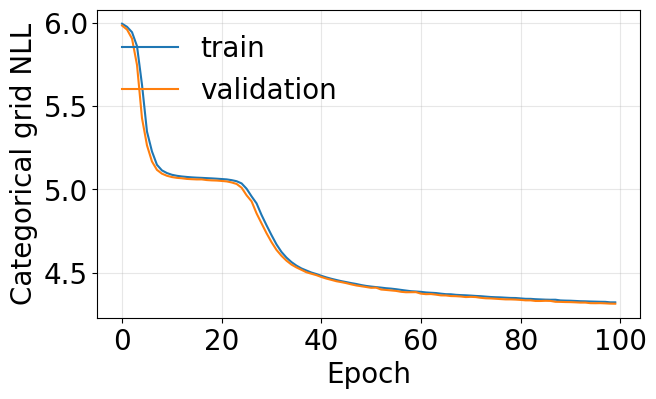

In [26]:
plt.figure(figsize=(7, 4))
plt.plot(train_losses, label="train")
plt.plot(val_losses, label="validation")
plt.xlabel("Epoch")
plt.ylabel("Categorical grid NLL")
plt.grid(alpha=0.3)
plt.legend()
plt.show

In [27]:
checkpoint_path = experiment_dir / "n18_grugrid_best.pt"

In [28]:
checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=True)

# Reconstructing from the saved configuration avoids hidden default mismatches.
model = TrajectoryGRUGrid(**checkpoint["model_config"]).to(device)
model.load_state_dict(checkpoint["model_state_dict"])

test_loss = evaluate(model, test_loader, device)
print("Best checkpoint epoch:", checkpoint["epoch"])
print(f"Test grid NLL: {test_loss:.5f}")

Best checkpoint epoch: 100
Test grid NLL: 4.28453


Generated range: -1.0 0.37


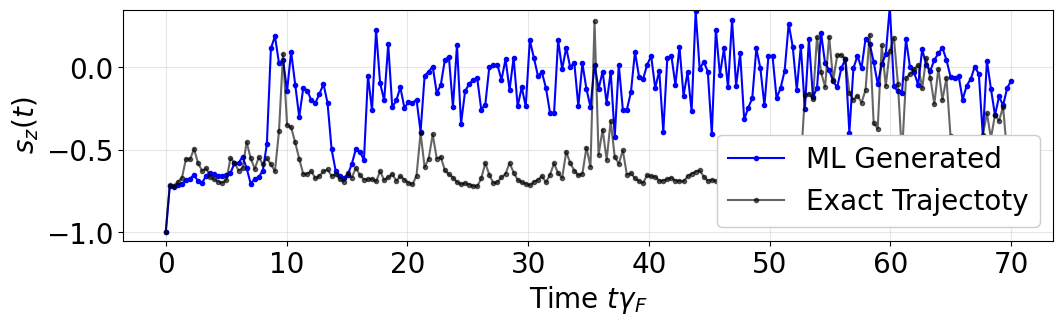

In [35]:
reference_index = test_set.indices[0]
reference = torch.from_numpy(sz[reference_index])
sample_generator = torch.Generator(device=device).manual_seed(1)

generated = generate_trajectories(
    model,
    initial_sz=reference[0:1],
    n_time_points=reference.numel(),
    time_end=time_end,
    temperature=1,
    generator=sample_generator,
).cpu().numpy()[0]
physical_time = np.linspace(0.0, 70.0, len(generated))

print("Generated range:", generated.min(), generated.max())
assert generated.min() >= state_min and generated.max() <= state_max

plt.figure(figsize=(12, 3))
plt.plot(physical_time, generated, "b-o", ms=3, label="ML Generated")
plt.plot(
    physical_time,
    reference.numpy(),
    "k-o",
    ms=3,
    alpha=0.6,
    label="Exact Trajectoty",
)
#plt.axhline(state_min, color="red", ls=":", alpha=0.5)
#plt.axhline(state_max, color="red", ls=":", alpha=0.5)
plt.xlabel("Time $t \\gamma_F$")
plt.ylabel("$s_z(t)$")
plt.ylim(state_min - 0.05, 0.3 + 0.05)
plt.grid(alpha=0.3)
plt.legend(loc = 0,framealpha = 1)
plt.savefig('one_traj_example.pdf',bbox_inches = 'tight')

generated_min: -1.000000
generated_max: 0.515000
mean_curve_mae: 0.040635
std_curve_mae: 0.025747


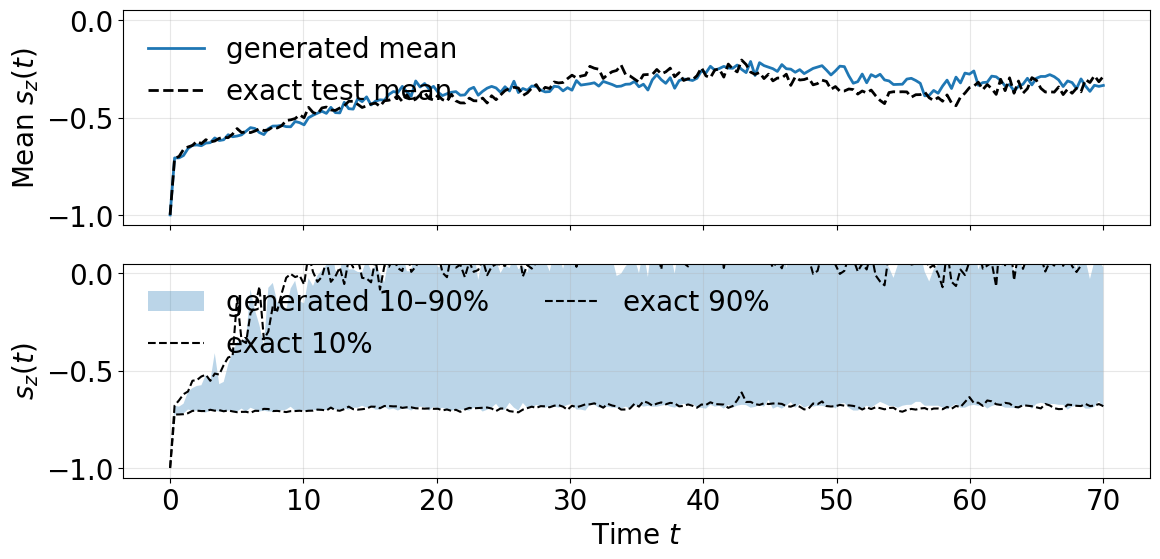

In [36]:
test_indices = torch.as_tensor(test_set.indices, dtype=torch.long)
exact_test = dataset.sz[test_indices].to(device)
ensemble_generator = torch.Generator(device=device).manual_seed(seed + 1)

generated_test = generate_trajectories(
    model,
    initial_sz=exact_test[:, 0],
    n_time_points=exact_test.shape[1],
    time_end=time_end,
    temperature=1.0,
    generator=ensemble_generator,
)

summary = rollout_summary(generated_test, exact_test)
for name, value in summary.items():
    print(f"{name}: {value:.6f}")

generated_np = generated_test.cpu().numpy()
exact_np = exact_test.cpu().numpy()

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].plot(physical_time, generated_np.mean(axis=0), lw=2, label="generated mean")
axes[0].plot(physical_time, exact_np.mean(axis=0), "k--", lw=2, label="exact test mean")
axes[0].set_ylabel(r"Mean $s_z(t)$")
axes[0].set_ylim(state_min - 0.05, 0 + 0.05)
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].fill_between(
    physical_time,
    np.percentile(generated_np, 10, axis=0),
    np.percentile(generated_np, 90, axis=0),
    alpha=0.3,
    label="generated 10–90%",
)
axes[1].plot(
    physical_time,
    np.percentile(exact_np, 10, axis=0),
    "k--",
    lw=1.5,
    label="exact 10%",
)
axes[1].plot(
    physical_time,
    np.percentile(exact_np, 90, axis=0),
    "k--",
    lw=1.5,
    label="exact 90%",
)
axes[1].set_xlabel("Time $t$")
axes[1].set_ylabel("$s_z(t)$")
axes[1].set_ylim(state_min - 0.05, 0+ 0.05)
axes[1].grid(alpha=0.3)
axes[1].legend(ncol = 2)

plt.tight_layout()
plt.show()

In [37]:
# Generate the same number of model trajectories as real trajectories.
n_generated = len(sz)  # 500

# Use the real initial-state distribution.
# If all physical trajectories start at -1, this is equivalent to using -1.
initial_sz = torch.from_numpy(sz[:n_generated, 0])

generation_generator = torch.Generator(device=device).manual_seed(123)

generated_ensemble = generate_trajectories(
    model,
    initial_sz=initial_sz,
    n_time_points=sz.shape[1],
    time_end=time_end,
    temperature=1.0,
    generator=generation_generator,
).cpu().numpy()

print("Real shape:", sz.shape)
print("Generated shape:", generated_ensemble.shape)
print(
    "Generated range:",
    generated_ensemble.min(),
    generated_ensemble.max(),
)

Real shape: (500, 210)
Generated shape: (500, 210)
Generated range: -1.0 0.985


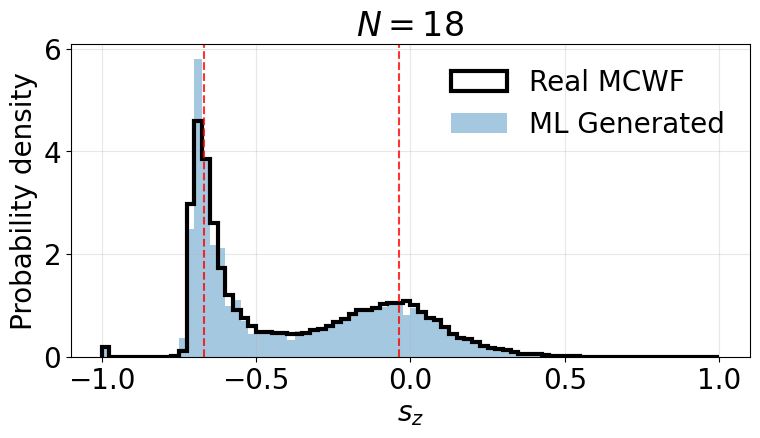

In [45]:
time_mask = physical_time >= 0

real_values = sz[:, time_mask].ravel()
generated_values = generated_ensemble[:, time_mask].ravel()

common_bins = np.linspace(-1, 1, 81)

plt.figure(figsize=(8, 4.5))

plt.hist(
    real_values,
    bins=common_bins,
    density=True,
    histtype="step",
    linewidth=3,
    color="black",
    label="Real MCWF",
)

plt.hist(
    generated_values,
    bins=common_bins,
    density=True,
    histtype="stepfilled",
    linewidth=2,
    color="tab:blue",
    alpha=0.4,
    label="ML Generated",
)
# --- Add vertical lines here ---
vlines = [-0.66878138, -0.03828487]
for x in vlines:
    plt.axvline(x=x, color="red", linestyle="--", linewidth=1.5, alpha=0.8)
# -------------------------------

plt.xlabel(r"$s_z$")
plt.ylabel("Probability density")
plt.grid(alpha=0.3)
plt.legend(loc= 0)
plt.tight_layout()
plt.title(r'$N = 18$')
plt.savefig('two_peaks.pdf',bbox_inches = 'tight')

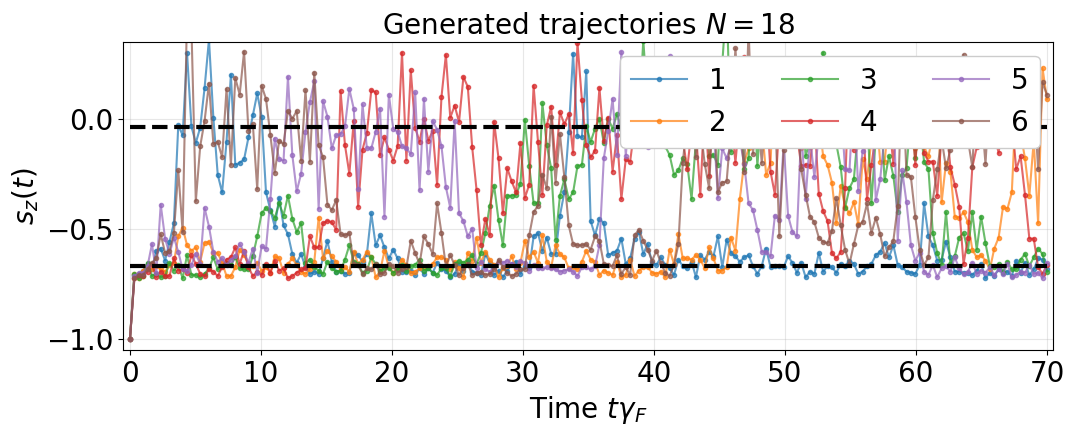

In [46]:
reference_index = test_set.indices[0]
reference = torch.from_numpy(sz[reference_index])
n_points = reference.numel()

# Compute physical time array upfront
physical_time = np.linspace(0.0, 70.0, n_points)

# Single generator instance (sequential random draws across loop runs)
sample_generator = torch.Generator(device=device).manual_seed(0)

plt.figure(figsize=(12, 4))

# Generate and plot 5 trajectories
for i in range(6):
    generated = generate_trajectories(
        model,
        initial_sz=reference[0:1],
        n_time_points=n_points,
        time_end=time_end,
        temperature=1.0,
        generator=sample_generator,
    ).cpu().numpy()[0]
    
    # Verify state bounds for each generated trajectory
    assert generated.min() >= state_min and generated.max() <= state_max
    
    plt.plot(
        physical_time, 
        generated, 
        "-o", 
        ms=3, 
        alpha=0.7, 
        label=f"{i + 1}"
    )

plt.xlabel("Time $t \\gamma_F$")
plt.ylabel("$s_z(t)$")
plt.hlines(-0.66878138, xmin = 0, xmax = 70,color = 'black', linestyle = '--',linewidth = 3)
plt.hlines(-0.03828487, xmin = 0, xmax = 70,color = 'black', linestyle = '--',linewidth = 3)
plt.ylim(state_min - 0.05, 0.3 + 0.05)
plt.grid(alpha=0.3)
plt.xlim(0-0.5,70+0.5)
plt.legend(loc=1,ncol = 3,framealpha = 1)
plt.title('Generated trajectories $N = 18$',fontsize = 20)
plt.show()

In [16]:
def solve_sz_roots(Omega, Gamma_tilde, Delta_tilde):
    """
    Solve the cubic equation for s_z at given Omega.
    gamma is fixed to 1.
    Returns all (possibly complex) roots.
    """
    gamma = 1.0
    Omega_c = np.sqrt(Gamma_tilde**2 + 4*Delta_tilde**2) / 4

    a3 = 16 * Omega_c**2
    a2 = 16 * Omega_c**2 - 2 * gamma * Gamma_tilde
    a1 = gamma**2 - 2 * gamma * Gamma_tilde + 8 * Omega**2
    a0 = gamma**2

    coeffs = [a3, a2, a1, a0]
    roots = np.roots(coeffs)

    return roots
def physical_sz_roots(Omega, Gamma_tilde, Delta_tilde, tol=1e-8):
    roots = solve_sz_roots(Omega, Gamma_tilde, Delta_tilde)

    phys = []
    for r in roots:
        if abs(r.imag) < tol and abs(r.real) <= 1 + tol:
            phys.append(r.real)

    return phys

def scan_sz_vs_r(Gamma_tilde, Delta_tilde,
                 r_min=0.0, r_max=1.2, npts=400):
    """
    Scan physical s_z solutions as a function of r = Omega / Omega_c
    """
    Omega_c = np.sqrt(Gamma_tilde**2 + 4*Delta_tilde**2) / 4
    r_vals = np.linspace(r_min, r_max, npts)

    r_plot = []
    sz_plot = []

    for r in r_vals:
        Omega = r * Omega_c
        roots = physical_sz_roots(Omega, Gamma_tilde, Delta_tilde)
        for sz in roots:
            r_plot.append(r)
            sz_plot.append(sz)

    return np.array(r_plot), np.array(sz_plot)



In [17]:
G = 10*17/11
solve_sz_roots(0.73*G/4,G,0)

array([-0.66878138, -0.16352198, -0.03828487])

Text(0, 0.5, '$s_z$')

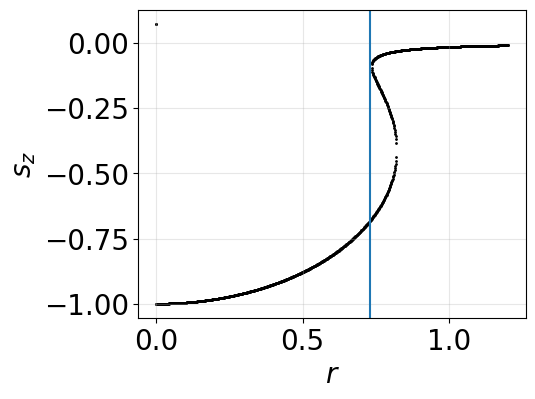

In [70]:
# Parameters
Gamma = 10*15/11
Delta = 0

r_vals, sz_vals = scan_sz_vs_r(Gamma, Delta,r_min=0.0, r_max=1.2, npts=1000)

plt.figure(figsize=(5,4))
plt.scatter(r_vals, sz_vals, s=1, color='black')
plt.axvline(x = 0.73)
plt.xlabel(r'$r$')
plt.ylabel(r'$s_z$')


In [59]:
n_generated = 50  # 500

# Use the real initial-state distribution.
# If all physical trajectories start at -1, this is equivalent to using -1.

initial_sz = torch.full(
    (n_generated,),
    -1.0,
    dtype=torch.float32,
)


generation_generator = torch.Generator(device=device).manual_seed(123)

generated_ensemble = generate_trajectories(
    model,
    initial_sz=initial_sz,
    n_time_points=sz.shape[1],
    time_end=time_end,
    temperature=1.0,
    generator=generation_generator,
).cpu().numpy()

print("Real shape:", sz.shape)
print("Generated shape:", generated_ensemble.shape)
print(
    "Generated range:",
    generated_ensemble.min(),
    generated_ensemble.max(),
)

Real shape: (500, 210)
Generated shape: (50, 210)
Generated range: -1.0 0.505


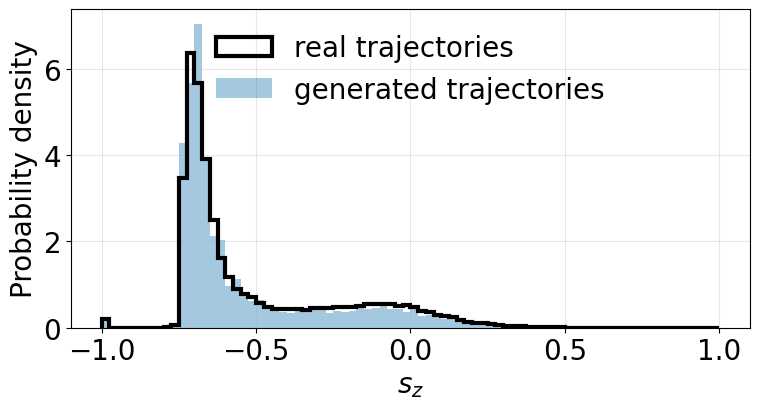

In [60]:
time_mask = physical_time >= 0

real_values = sz[:, time_mask].ravel()
generated_values = generated_ensemble[:, time_mask].ravel()

common_bins = np.linspace(-1, 1, 81)

plt.figure(figsize=(8, 4.5))

plt.hist(
    real_values,
    bins=common_bins,
    density=True,
    histtype="step",
    linewidth=3,
    color="black",
    label="real trajectories",
)

plt.hist(
    generated_values,
    bins=common_bins,
    density=True,
    histtype="stepfilled",
    linewidth=2,
    color="tab:blue",
    alpha=0.4,
    label="generated trajectories",
)

plt.xlabel(r"$s_z$")
plt.ylabel("Probability density")
plt.grid(alpha=0.3)
plt.legend(loc= 9)
plt.tight_layout()
plt.show()

In [61]:
n_generated = 5000  # 500

# Use the real initial-state distribution.
# If all physical trajectories start at -1, this is equivalent to using -1.

initial_sz = torch.full(
    (n_generated,),
    -1.0,
    dtype=torch.float32,
)


generation_generator = torch.Generator(device=device).manual_seed(123)

generated_ensemble = generate_trajectories(
    model,
    initial_sz=initial_sz,
    n_time_points=sz.shape[1],
    time_end=time_end,
    temperature=1.0,
    generator=generation_generator,
).cpu().numpy()

print("Real shape:", sz.shape)
print("Generated shape:", generated_ensemble.shape)
print(
    "Generated range:",
    generated_ensemble.min(),
    generated_ensemble.max(),
)

Real shape: (500, 210)
Generated shape: (5000, 210)
Generated range: -1.0 1.0


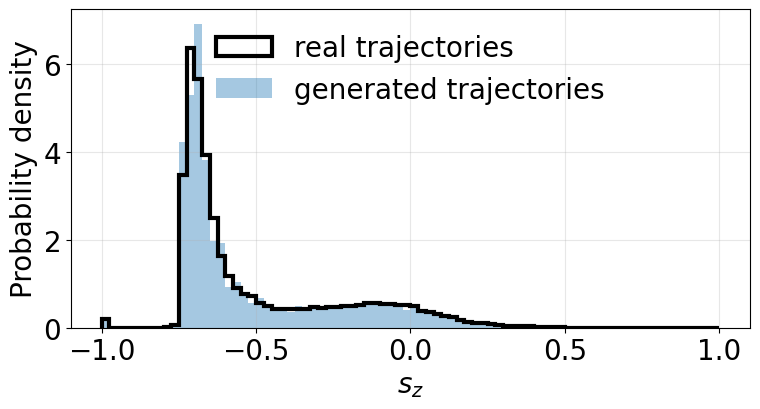

In [62]:
time_mask = physical_time >= 0

real_values = sz[:, time_mask].ravel()
generated_values = generated_ensemble[:, time_mask].ravel()

common_bins = np.linspace(-1, 1, 81)

plt.figure(figsize=(8, 4.5))

plt.hist(
    real_values,
    bins=common_bins,
    density=True,
    histtype="step",
    linewidth=3,
    color="black",
    label="real trajectories",
)

plt.hist(
    generated_values,
    bins=common_bins,
    density=True,
    histtype="stepfilled",
    linewidth=2,
    color="tab:blue",
    alpha=0.4,
    label="generated trajectories",
)

plt.xlabel(r"$s_z$")
plt.ylabel("Probability density")
plt.grid(alpha=0.3)
plt.legend(loc= 9)
plt.tight_layout()
plt.show()

In [65]:
len(generated_values)

1050000

In [66]:
5000*210

1050000

In [47]:
#Interesting -- set initial conditions to zero and see


In [ ]:
!zip -r downloaded_folder.zip my_folder